# Notebook 5 — RoBERTa Fine-Tuning

## Environment Setup for Transformer Modelling

This section prepares the environment for training and evaluating transformer-based models. Libraries for deep learning, tokenisation, and model scheduling are initialised to support the training pipeline.

Configuration parameters are imported to ensure consistency in hyperparameters, model settings, and file paths. Output directories are also prepared for storing model artefacts and visualisations.

Finally, the computation device is selected dynamically based on availability, enabling efficient training on GPU or compatible hardware when possible.

In [1]:
# System path setup
import sys, os, pickle, time, copy
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Transformers utilities
from transformers import (
    AutoTokenizer, AutoModel,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
    logging as hf_logging
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, 
    ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

# Configuration
import config
from config import (
    LABELLED_DATASET,
    VISUALISATION_DIR,
    ROBERTA_DIR,
    ROBERTA_MODEL_ID,
    ROBERTA_PREDS_PKL,
    ROBERTA_RESULTS_CSV,
    NUM_LABELS,
    MAX_LENGTH,
    BATCH_SIZE,
    NUM_EPOCHS,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_RATIO,
    EARLY_STOPPING_PATIENCE,
    ID2LABEL,
)

# Create output directories
ROBERTA_PLT_DIR = VISUALISATION_DIR / 'roberta_model'
os.makedirs(ROBERTA_PLT_DIR, exist_ok=True)
os.makedirs(ROBERTA_DIR, exist_ok=True)

# Global plotting configuration for consistency
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': ':',
})

# Select device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

/Users/latikasisodiya/Documents/PROJECTS/depression_detection_nlp_project/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


## Dataset Loading and Split Preparation

This step loads the processed dataset and separates it into training, validation, and test partitions based on predefined split labels.

Each subset is reset to ensure clean indexing, which is important for consistent batching during model training. This structured separation supports proper model evaluation and prevents data leakage.

In [2]:
# Load dataset
df = pd.read_csv(LABELLED_DATASET)

# Split dataset
train = df[df['split'] == 'train'].reset_index(drop=True)
val   = df[df['split'] == 'val'].reset_index(drop=True)
test  = df[df['split'] == 'test'].reset_index(drop=True)

# Print dataset sizes
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 13,994  Val: 2,990  Test: 2,998


## Tokenizer and Batching Setup

The tokenizer converts raw text into token IDs compatible with the transformer model. Dynamic padding is applied during batching to optimise memory usage and ensure uniform input shapes across batches.

This setup ensures efficient preprocessing and seamless integration with the training pipeline.

In [3]:
# Load tokenizer and data collator
tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_ID)
collator  = DataCollatorWithPadding(
    tokenizer=tokenizer, 
    return_tensors='pt'
)

# Display vocabulary size
print(f'Vocab size: {tokenizer.vocab_size:,}')

Vocab size: 50,265


## Custom Dataset for Transformer Input

This section defines a dataset class tailored for transformer-based models. It handles tokenisation and prepares inputs in a format compatible with PyTorch training pipelines.

Text data is converted into token IDs and attention masks using a tokenizer, ensuring that sequences are appropriately truncated. Labels are stored alongside these inputs for supervised learning.

An optional linguistic feature can also be included, allowing the model to incorporate additional signals beyond textual embeddings when required.

In [4]:
# Dataset wrapper for transformer-based models
class SuicideDataset(Dataset):
    def __init__(
        self,
        df,
        tokenizer,
        text_col: str = 'text_clean',
        label_col: str = 'label_id',
        max_length: int = 128,
        use_intensifier: bool = False
    ):
        # Texts prepared for tokenisation
        texts = df[text_col].fillna('').tolist()
        encodings = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding=False,
            return_tensors=None,
        )

        self.input_ids = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']
        self.labels = df[label_col].tolist()

        # Optional linguistic feature stored when available
        self.intensifier = (
            df['intensifier_score'].fillna(0).tolist()
            if use_intensifier and 'intensifier_score' in df.columns
            else None
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx],
        }

        if self.intensifier is not None:
            item['intensifier'] = self.intensifier[idx]

        return item

## Transformer Classifier with Optional Feature Fusion

This model extends a pretrained transformer encoder with a custom classification head. It produces contextual embeddings for each input sequence and uses the first token representation as a compact summary.

An optional scalar feature can be concatenated with the embedding to incorporate additional linguistic signals. The combined representation is passed through a feedforward network to generate class logits.

In [5]:
# Transformer encoder with classification head
class RoBERTaClassifier(nn.Module):
    def __init__(
        self,
        model_id: str,
        num_labels: int = 2,
        use_linguistic: bool = False,
        dropout: float = 0.1
    ):
        super().__init__()

        # Encoder initialised from pretrained weights
        self.encoder = AutoModel.from_pretrained(model_id)
        hidden = self.encoder.config.hidden_size
        self.use_linguistic = use_linguistic
        in_dim = hidden + 1 if use_linguistic else hidden

        # Fully connected layers for prediction
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        intensifier=None
    ):
        # Forward pass through encoder
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Sequence representation extracted
        pooled = out.last_hidden_state[:, 0, :]

        # Additional feature concatenated if enabled
        if self.use_linguistic and intensifier is not None:
            pooled = torch.cat(
                [pooled, intensifier.unsqueeze(1)],
                dim=1
            )

        return self.classifier(pooled)

## Training and Evaluation Routines

These functions implement the core training and evaluation logic for the model.

The training routine performs forward propagation, loss computation, backpropagation, gradient clipping, and parameter updates for each batch. Learning rate scheduling is applied at every step to stabilise optimisation.

The evaluation routine computes predictions without gradient updates and aggregates results across the dataset. It returns standard classification metrics along with predicted probabilities for further analysis.

In [6]:
# Train model for one epoch
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, total_correct, total = 0, 0, 0

    for batch in loader:
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs  = batch['labels'].to(device)

        inten = batch.get('intensifier')
        if inten is not None:
            inten = inten.to(device)

        optimizer.zero_grad()
        logits = model(ids, masks, inten)
        loss   = criterion(logits, labs)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss    += loss.item() * len(labs)
        total_correct += (logits.argmax(1) == labs).sum().item()
        total += len(labs)
    return total_loss / total, total_correct / total

# Evaluate model
@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device) -> dict:
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    for batch in loader:
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs  = batch['labels'].to(device)

        inten = batch.get('intensifier')
        if inten is not None:
            inten = inten.to(device)

        logits = model(ids, masks, inten)
        loss   = criterion(logits, labs)

        probs = torch.softmax(logits, dim=1)[:, 1]
        total_loss += loss.item() * len(labs)
        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(labs.cpu())
        all_probs.append(probs.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs  = torch.cat(all_probs).numpy()

    return {
        'loss' : total_loss / len(loader.dataset),
        'accuracy' : accuracy_score(all_labels, all_preds),
        'f1' : f1_score(all_labels, all_preds, pos_label=1),
        'recall' : recall_score(all_labels, all_preds, pos_label=1),
        'precision' : precision_score(all_labels, all_preds, pos_label=1),
        'roc_auc' : roc_auc_score(all_labels, all_probs),
        'preds' : all_preds.tolist(),
        'labels' : all_labels.tolist(),
        'probs' : all_probs.tolist(),
    }

## Experiment Execution Pipeline

This function orchestrates the full training workflow for a given configuration. It supports controlled experimentation by varying input representations and optional feature integration.

The dataset is first tokenised and converted into batched loaders. A fresh model is initialised for each run, with encoder weights reset to ensure fair comparison across experiments.

Training proceeds over multiple epochs with validation at each step. The best-performing model is selected using validation F1-score, and early stopping prevents unnecessary computation when performance plateaus.

The function returns the trained model, training history, and final validation metrics for analysis and comparison.

In [ ]:
# Experiment runner for controlled model comparison
_base_state = None

def run_experiment(
    text_col: str,
    use_intensifier: bool,
    experiment_name: str
):
    global _base_state

    print(f"\n{'='*60}")
    print(f'Experiment : {experiment_name}')
    print(f"{'='*60}")

    # Tokenisation stage
    t0 = time.time()

    train_ds = SuicideDataset(
        train,
        tokenizer,
        text_col=text_col,
        max_length=MAX_LENGTH,
        use_intensifier=use_intensifier
    )

    val_ds = SuicideDataset(
        val,
        tokenizer,
        text_col=text_col,
        max_length=MAX_LENGTH,
        use_intensifier=use_intensifier
    )

    print(f'Tokenised in {time.time() - t0:.1f}s')

    # Data loaders configured
    loader_kwargs = dict(
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda'),
        collate_fn=collator,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        **loader_kwargs
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        **loader_kwargs
    )

    # Model initialised
    model = RoBERTaClassifier(
        ROBERTA_MODEL_ID,
        num_labels=NUM_LABELS,
        use_linguistic=use_intensifier
    ).to(DEVICE)

    # Encoder weights reset for fair comparison
    if _base_state is None:
        _base_state = copy.deepcopy(model.encoder.state_dict())
    else:
        model.encoder.load_state_dict(_base_state)

    # Optimiser and scheduler
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        int(total_steps * WARMUP_RATIO),
        total_steps
    )
    criterion = nn.CrossEntropyLoss()

    # Checkpoint path
    ckpt = os.path.join(
        ROBERTA_DIR,
        f'best_{experiment_name.replace(" ", "_")}.pt'
    )

    history, best_f1, patience = [], 0.0, 0

    # Training loop with validation tracking
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        train_loss, train_acc = train_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            criterion,
            DEVICE
        )

        val_mat = evaluate_epoch(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            **{
                f'val_{k}': v
                for k, v in val_mat.items()
                if k not in ('preds', 'labels', 'probs')
            }
        })

        print(
            f'  Epoch {epoch}/{NUM_EPOCHS}  '
            f'loss={train_loss:.4f}  '
            f'val_f1={val_mat["f1"]:.4f}  '
            f'recall={val_mat["recall"]:.4f}  '
            f'({time.time() - t0:.0f}s)'
        )

        # Best model checkpoint updated
        if val_mat['f1'] > best_f1:
            best_f1 = val_mat['f1']
            torch.save(model.state_dict(), ckpt)
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOPPING_PATIENCE:
                print(f'  Early stopping at epoch {epoch}.')
                break

    # Best checkpoint restored
    model.load_state_dict(
        torch.load(
            ckpt, 
            map_location=DEVICE, 
            weights_only=True
        )
    )

    final_val = evaluate_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    return model, pd.DataFrame(history), final_val, experiment_name

## Baseline Transformer Experiment

This experiment trains a RoBERTa-based classifier using only cleaned textual input without additional linguistic features.

It serves as a reference point to evaluate the impact of feature augmentation in subsequent experiments. Performance metrics obtained here establish the baseline for comparison.

In [8]:
# Baseline experiment using text-only input
model_base, hist_base, val_base, name_base = run_experiment(
    'text_clean',
    use_intensifier=False,
    experiment_name='RoBERTa Baseline'
)


Experiment : RoBERTa Baseline
Tokenised in 1.0s


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7353.45it/s]


  Epoch 1/3  loss=0.2296  val_f1=0.9735  recall=0.9820  (942s)
  Epoch 2/3  loss=0.0722  val_f1=0.9797  recall=0.9699  (1022s)
  Epoch 3/3  loss=0.0259  val_f1=0.9805  recall=0.9759  (1045s)


## Negation-Aware Transformer Experiment

This experiment incorporates negation-aware text representations to enhance contextual understanding. By modifying the input text to explicitly mark negated tokens, the model can better capture shifts in meaning caused by negation.

The performance of this setup is compared against the baseline to assess whether negation handling improves classification outcomes.

In [9]:
# Experiment using negation-tagged input
model_neg, hist_neg, val_neg, name_neg = run_experiment(
    'text_neg_tagged',
    use_intensifier=False,
    experiment_name='RoBERTa + Negation'
)


Experiment : RoBERTa + Negation
Tokenised in 1.9s


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5885.88it/s]


  Epoch 1/3  loss=0.2324  val_f1=0.9757  recall=0.9779  (1045s)
  Epoch 2/3  loss=0.0777  val_f1=0.9772  recall=0.9759  (1046s)
  Epoch 3/3  loss=0.0321  val_f1=0.9806  recall=0.9786  (1043s)


## Feature-Augmented Transformer Experiment

This configuration combines negation-aware text with an additional linguistic signal. The input representation is enriched both at the token level and through a scalar feature, enabling the model to capture nuanced emotional intensity alongside contextual meaning.

This setup evaluates whether integrating multiple linguistic cues leads to measurable improvements over simpler configurations.

In [10]:
# Experiment with negation tagging and linguistic feature
model_full, hist_full, val_full, name_full = run_experiment(
    'text_neg_tagged',
    use_intensifier=True,
    experiment_name='RoBERTa + Negation + Intensifier'
)


Experiment : RoBERTa + Negation + Intensifier
Tokenised in 2.1s


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6334.64it/s]


  Epoch 1/3  loss=0.2288  val_f1=0.9727  recall=0.9532  (1149s)
  Epoch 2/3  loss=0.0774  val_f1=0.9789  recall=0.9779  (1127s)
  Epoch 3/3  loss=0.0303  val_f1=0.9815  recall=0.9773  (1104s)


## Training Dynamics Across Experiments

This visualisation compares learning behaviour across different configurations. Training loss illustrates optimisation stability, while validation F1 reflects generalisation performance.

By analysing these curves together, it becomes easier to identify convergence speed, overfitting patterns, and the relative effectiveness of each experimental setup.

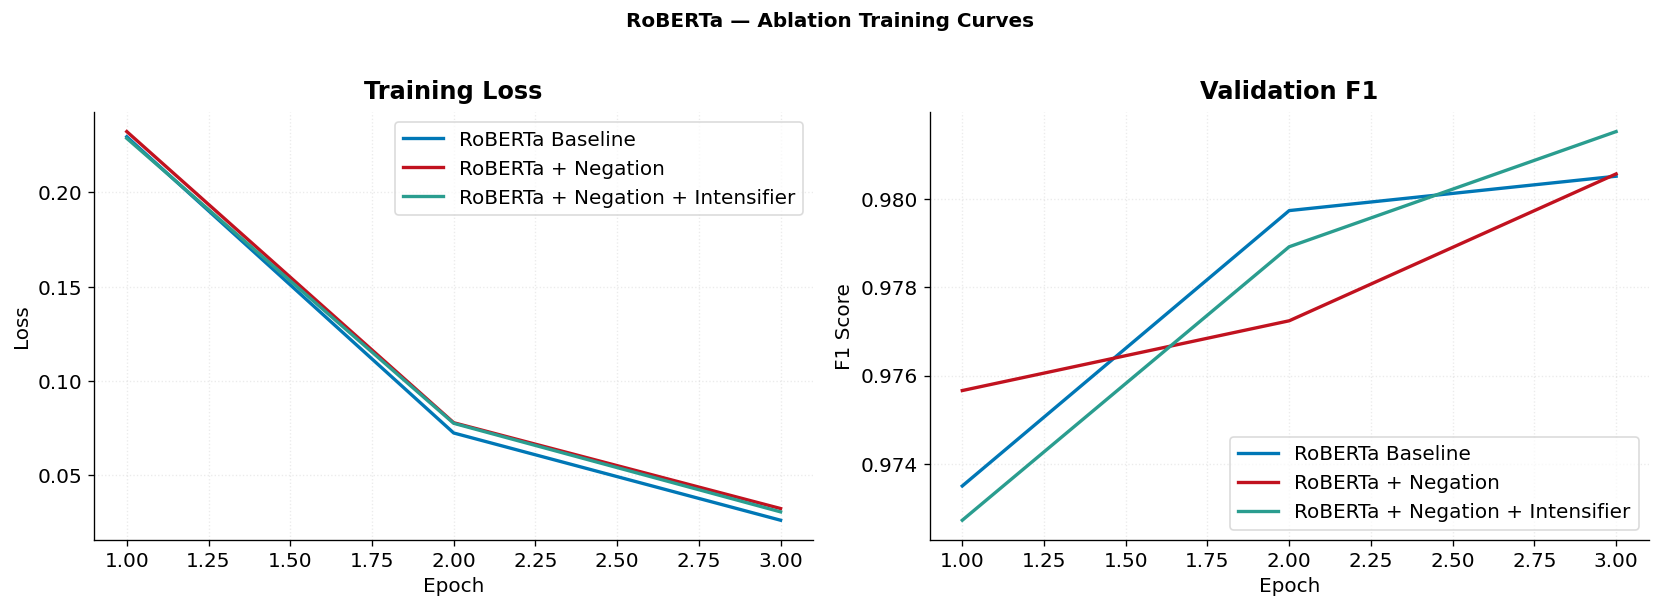

In [11]:
# Visual comparison of training behaviour
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
color_palette = ['#0077B6', '#C1121F', '#2A9D8F']

for hist, name, c in zip(
    [hist_base, hist_neg, hist_full],
    [name_base, name_neg, name_full],
    color_palette
):
    axes[0].plot(
        hist['epoch'],
        hist['train_loss'],
        label=name,
        color=c,
        linewidth=2
    )

    axes[1].plot(
        hist['epoch'],
        hist['val_f1'],
        label=name,
        color=c,
        linewidth=2
    )

# Plot configuration
for ax, title, ylabel in zip(
    axes,
    ['Training Loss', 'Validation F1'],
    ['Loss', 'F1 Score']
):
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(framealpha=0.7)

plt.suptitle(
    'RoBERTa — Ablation Training Curves',
    fontsize=12,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig(
    ROBERTA_PLT_DIR / 'training_curves.png',
    bbox_inches='tight'
)
plt.show()

## Ablation Study Results

This table summarises the performance of each experimental configuration. It provides a direct comparison across key evaluation metrics, enabling clear assessment of how each modification influences model behaviour.

The results highlight the contribution of negation handling and feature augmentation relative to the baseline model.

In [12]:
# Aggregate results across experiments
ablation_rows = []

for name, m in [
    (name_base, val_base),
    (name_neg,  val_neg),
    (name_full, val_full)
]:
    ablation_rows.append({
        'Experiment': name,
        'Accuracy': round(m['accuracy'], 4),
        'Precision': round(m['precision'], 4),
        'Recall': round(m['recall'], 4),
        'F1': round(m['f1'], 4),
        'ROC-AUC': round(m['roc_auc'], 4),
    })

ablation_df = pd.DataFrame(ablation_rows)

# Display results
print(ablation_df.to_string(index=False))

                      Experiment  Accuracy  Precision  Recall     F1  ROC-AUC
                RoBERTa Baseline    0.9806     0.9852  0.9759 0.9805   0.9976
              RoBERTa + Negation    0.9806     0.9826  0.9786 0.9806   0.9974
RoBERTa + Negation + Intensifier    0.9816     0.9858  0.9773 0.9815   0.9973


## Confusion Matrix Comparison

This visualisation compares prediction behaviour across experimental setups. Each matrix shows the distribution of true and predicted labels, allowing detailed inspection of classification errors.

The comparison highlights differences in false positives and false negatives, providing deeper insight into how each configuration impacts model reliability.

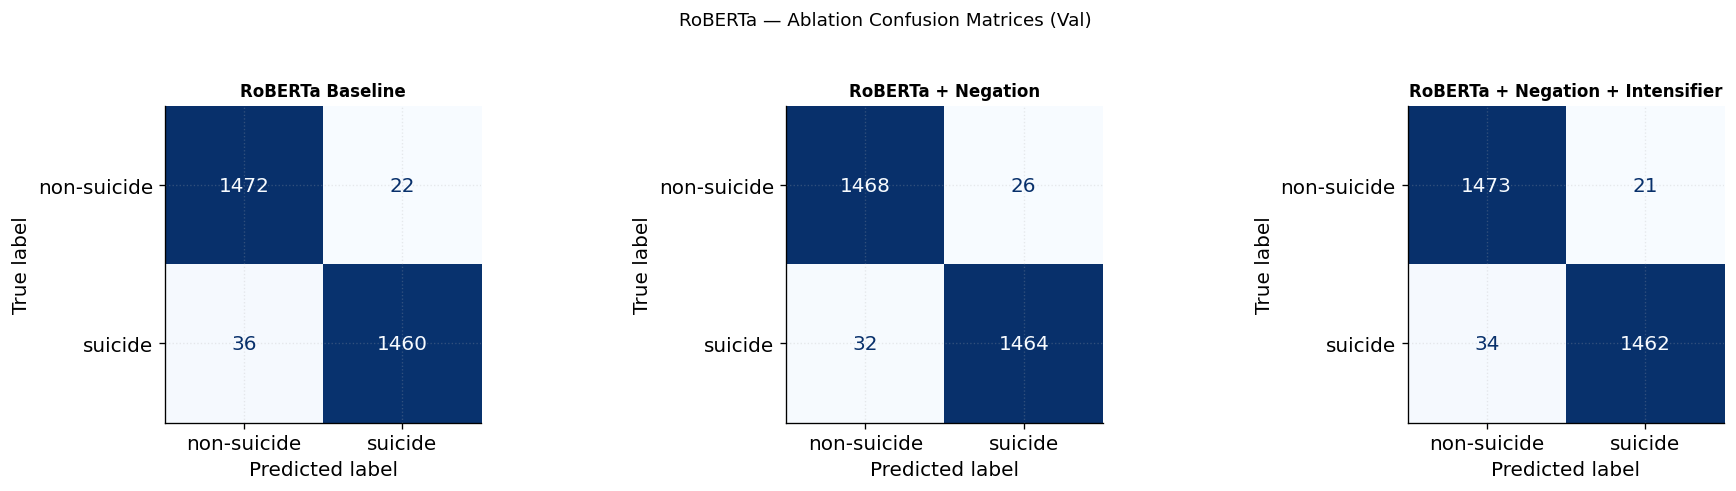

In [13]:
# Visual comparison of prediction errors
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, m in zip(
    axes,
    [name_base, name_neg, name_full],
    [val_base,  val_neg,  val_full]
):
    ConfusionMatrixDisplay(
        confusion_matrix(m['labels'], m['preds']),
        display_labels=['non-suicide', 'suicide']
    ).plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        name,
        fontweight='bold',
        fontsize=10
    )

plt.suptitle(
    'RoBERTa — Ablation Confusion Matrices (Val)',
    fontsize=11,
    y=1.02
)

plt.tight_layout()
plt.savefig(
    ROBERTA_PLT_DIR / 'ablation_cm.png',
    bbox_inches='tight'
)
plt.show()

## Best Model Selection and Test Evaluation

The best-performing configuration is selected based on validation F1-score. The corresponding model setup is then used to evaluate performance on the test set.

This provides an unbiased estimate of how well the final model generalises to unseen data, along with a detailed classification report.

In [14]:
# Select best experiment based on F1
best_idx = ablation_df['F1'].idxmax()
best_condition = ablation_df.loc[best_idx, 'Experiment']
print(f'Best condition: {best_condition}')

# Map experiment to model configuration
best_map = {
    name_base: (model_base, 'text_clean',      False),
    name_neg:  (model_neg, 'text_neg_tagged', False),
    name_full: (model_full, 'text_neg_tagged', True),
}
best_model, best_col, best_intens = best_map[best_condition]

# Prepare test dataset
test_ds = SuicideDataset(
    test,
    tokenizer,
    text_col=best_col,
    max_length=MAX_LENGTH,
    use_intensifier=best_intens
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE * 2,
    collate_fn=collator
)

# Evaluate on test set
test_metrics = evaluate_epoch(
    best_model,
    test_loader,
    nn.CrossEntropyLoss(),
    DEVICE
)

# Print classification report
print(classification_report(
    test_metrics['labels'],
    test_metrics['preds'],
    target_names=['non-suicide', 'suicide']
))

Best condition: RoBERTa + Negation + Intensifier
              precision    recall  f1-score   support

 non-suicide       0.98      0.98      0.98      1498
     suicide       0.98      0.98      0.98      1500

    accuracy                           0.98      2998
   macro avg       0.98      0.98      0.98      2998
weighted avg       0.98      0.98      0.98      2998



## Saving Predictions and Experiment Outputs

This step stores the outputs generated during experimentation for future analysis and reproducibility.

Predictions, probabilities, and evaluation results are serialised into a file for easy loading, while the ablation summary is saved in tabular format. This ensures that results can be reused without rerunning the full training pipeline.

In [15]:
# Save predictions and results
roberta_preds = {
    'ablation': ablation_df,
    'test_preds':  test_metrics['preds'],
    'test_labels': test_metrics['labels'],
    'test_probs':  test_metrics['probs'],
    'best_condition': best_condition,
}

with open(ROBERTA_PREDS_PKL, 'wb') as f:
    pickle.dump(roberta_preds, f)


# Save ablation results
ablation_df.to_csv(ROBERTA_RESULTS_CSV, index=False)